<div style="
background-color:#EAEAEA;
padding:15px;
border-left:5px solid #6C757D;
border-radius:6px;">

# Master's Thesis in Advanced Physics
---

This notebook is part of the **Master's Thesis (MSc Dissertation)**: **Fast Simulation of Neutrino Oscillations in Matter**.

**Author**
Juan Ramon Diaz Santos <diazjuan@alumni.uv.es>

**Supervisors**
Roberto Ruiz de Austri Bazan <rruiz@ific.uv.es>
Michele Lucente <michele.lucente@unibo.it>

**Date**
June 2026
</div>

# Earth Diagnostic 3 - Nadir Exposure and Flux
---

This notebook continues the Earth diagnostic series. It covers the
nadir-angle exposure machinery (`tpeanuts.medium.earth.exposure_math`,
`exposure_table`, `exposure_io`) used to time-average Earth matter-regeneration
probabilities over a detector's daily/annual exposure, the integration layer
that applies it (`tpeanuts.medium.earth.exposure_integration`), and the flux
wrapper built on top of it (`tpeanuts.medium.earth.flux`).

The notebook is intentionally diagnostic rather than a pytest suite. The
automated sanity checks live in `tpeanuts.medium.earth.test.test5_flux` and
`tpeanuts.medium.earth.test.test6_exposure`; here we keep the plots and
physical interpretation. This notebook replaces and extends the plots from the
historical backup script `tests_backup/4_earth/test4_exposure.py`.

While building the pytest suite, a real quadrature bug was found and fixed in
`pearth_integrated`: it used a hardcoded step `deta = pi / exposure_ns`, which
does not match the actual point spacing `pi / (exposure_ns - 1)` of the
underlying nadir-angle grid, causing a systematic `(ns-1)/ns` underestimate of
every exposure-integrated quantity (a 0.1% bias even at the production default
`exposure_ns=1000`, worse at coarser grids). Section 6 of this notebook
demonstrates the fix directly: the exposure-averaged probability now sums to
exactly 1 for every grid size, not just asymptotically as `ns -> infinity`.

---

## Table of Contents

| # | Section |
|---|---------|
| [0](#0.-Theory-Background) | **Theory Background**: exposure weight, table, integration, flux |
| [1](#1.-Libraries) | **Libraries** |
| [2](#2.-Paths-and-Configuration) | **Paths and Configuration** |
| [3](#3.-Nadir-Exposure-Weight-versus-Latitude) | **Nadir Exposure Weight versus Latitude**: `IntegralDay` |
| [4](#4.-CSV-Angle-Mode-Conversion-and-Day-Night-Slicing) | **CSV Angle-Mode Conversion and Day/Night Slicing** |
| [5](#5.-NadirExposureTable-Normalization-and-Interpolation) | **NadirExposureTable Normalization and Interpolation** |
| [6](#6.-Exposure-Integrated-Probability-Convergence) | **Exposure-Integrated Probability Convergence**: the `deta` fix |
| [7](#7.-Exposure-Integrated-Probability-versus-Latitude) | **Exposure-Integrated Probability versus Latitude** |
| [8](#8.-Earth-Flux-from-Probability) | **Earth Flux from Probability** |
| [9](#9.-Chunked-versus-Full-Batch-Integration) | **Chunked versus Full-Batch Integration** consistency |
| [10](#10.-Summary) | **Summary** |


## 0. Theory Background

### 0.1 The Nadir-Angle Exposure Weight

A detector at geographic latitude $\lambda$ does not observe every nadir angle
$\eta$ equally often: the Earth's daily rotation and annual orbital motion
(orbital-plane inclination $i$) determine, for each $\eta$, the fraction of a
chosen day-of-year window $[d_1,d_2]$ during which a neutrino source at the
time-varying solar declination is seen at that nadir angle. This fraction is
the exposure weight $W(\eta)$, built by:

$$
W(\eta) = \sum_{\text{windows}} \Bigl[\,\text{IndefiniteIntegralDay}(T_{\rm up})-\text{IndefiniteIntegralDay}(T_{\rm low})\,\Bigr],
$$

where `IndefiniteIntegralDay` is a closed-form antiderivative (in an auxiliary
day-phase variable $T$) built from incomplete elliptic integrals of the first
kind, `IntegralAngle` evaluates it over one valid year-angle sub-window, and
`IntegralDay` sums the contributions of all sub-windows inside $[d_1,d_2]$.
No standard GPU library ships incomplete elliptic integrals, so
`exposure_math` implements them directly in PyTorch.

---

### 0.2 NadirExposureTable

A `NadirExposureTable(eta, exposure)` pairs a nadir-angle grid with tabulated
$W(\eta)$ values, either evaluated directly (`exposure_source="math"`), cached
from a previous run, loaded from a CSV file (in "Nadir", "Zenith", or
"CosZenith" angle convention), or computed by the legacy peanuts
implementation for validation. `normalize_()` rescales $W$ so that
$\int d\eta\,W(\eta)=1$ (trapezoidal rule), turning it into a proper
probability density over nadir angle; `interp(...)` linearly interpolates it
at arbitrary query angles, clamped at the grid boundaries.

---

### 0.3 Exposure-Integrated Probability

`pearth_integrated` computes the exposure-averaged Earth regeneration
probability for one or more energies,

$$
P_{\rm int}(E) = \int_0^{\pi} d\eta\; W(\eta)\, P_{\rm earth}(E,\eta),
$$

approximated as a Riemann sum $P_{\rm int}(E)\approx\Delta\eta\sum_i W(\eta_i)\,P_{\rm earth}(E,\eta_i)$
over the exposure table's uniform grid, optionally chunked over $\eta$ to
control memory usage for large energy-angle batches. Because
$\sum_\alpha P_{\rm earth}(E,\eta)_\alpha=1$ pointwise (unitarity), a
normalized exposure table ($\int d\eta\,W(\eta)=1$) guarantees
$\sum_\alpha P_{\rm int}(E)_\alpha=1$ exactly -- **provided** the Riemann-sum
step $\Delta\eta$ used in the accumulation matches the grid's actual point
spacing. Section 6 verifies this invariant directly.

---

### 0.4 Earth Flux

`earth_flux`/`earth_flux_integrated` are thin wrappers: they call `pearth`
(or `pearth_integrated`) and then apply a flux normalization and optional
spectral weight via `flux_from_probability`,

$$
\Phi_\alpha = P_\alpha \times \text{flux} \times \text{spectrum},
$$

with `flux`/`spectrum` broadcasting against the *leading* (energy/angle)
dimensions of the probability tensor, not its trailing flavour axis.

---

### References

- Numerical Recipes-style treatment of incomplete elliptic integrals (used as
  the closed-form building block of the day-exposure primitive).
- L. Wolfenstein, "Neutrino oscillations in matter", *Physical Review D* **17**,
  2369 (1978) (matter-regeneration probability being averaged here).


## 1. Libraries

In [1]:
import math

import numpy as np
import torch
import matplotlib.pyplot as plt

import tpeanuts.util.constant as constant
from tpeanuts.core.common.oscillation import OscillationParameters
from tpeanuts.medium.earth.exposure_integration import pearth_integrated
from tpeanuts.medium.earth.exposure_io import _convert_csv_angle_mode, nadir_exposure_from_csv
from tpeanuts.medium.earth.exposure_math import IntegralDay, make_eta_grid
from tpeanuts.medium.earth.exposure_table import ExposureParameters, NadirExposureTable, build_nadir_exposure
from tpeanuts.medium.earth.flux import earth_flux, earth_flux_integrated
from tpeanuts.medium.earth.probability import pearth
from tpeanuts.medium.earth.profile import EarthParameters, EarthProfile
from tpeanuts.notebooks.notebookConfig import load_notebook_config
from tpeanuts.notebooks.notebooks_helper import save_and_show, to_numpy
from tpeanuts.util.context import RuntimeContext

print(f"Torch {torch.__version__}")

Torch 2.12.0+cu126


## 2. Paths and Configuration

### 2.1 Paths

`load_notebook_config()` resolves the repository root, applies the shared
plotting style, and provides the common output root. The output directory is
built from the notebook path relative to `notebooks/`, excluding the notebook
filename: `diagnostic/earth`.

**Expected results:** the printed paths should point to the local TPeanuts
repository and to an output directory ending in `diagnostic/earth`, and the
printed `EarthProfile` summary should report 5 shells spanning
`[~0.19, 1.00] R_E`, matching the earlier notebooks in this series.

In [2]:
config = load_notebook_config()
ctx = RuntimeContext.resolve(config.device, config.dtype)
OUTPUT_DIR = config.output_dir("diagnostic", "earth")

EARTH_DENSITY_CSV = config.earth_density_file

earth_profile = EarthProfile(
    params=EarthParameters(
        profile_perturbative_name="even_power",
        profile_perturbative_kwargs={"density_file": str(EARTH_DENSITY_CSV)},
    ),
    context=ctx,
)

oscillation = OscillationParameters.build(
    theta12=0.59,
    theta13=0.15,
    theta23=0.78,
    delta=1.20,
    DeltamSq21=7.42e-5,
    DeltamSq3l=2.517e-3,
    antinu=False,
    context=ctx,
)

DEPTH_SURFACE_M = 0.0
FLAVOUR_LABELS = [r"$\nu_e$", r"$\nu_\mu$", r"$\nu_\tau$"]
MASS_WEIGHTS = torch.tensor([0.55, 0.30, 0.15], device=ctx.device, dtype=ctx.dtype)

print(f"Package dir       : {config.package_dir}")
print(f"Output dir        : {OUTPUT_DIR}")
print(f"Earth density CSV : {EARTH_DENSITY_CSV}")
print(f"Device            : {ctx.device}   dtype: {ctx.dtype}")
print(earth_profile)

Package dir       : /mnt/g/Mi unidad/03.Codigo/034.TFM.UV/Tpeanuts
Output dir        : /mnt/v/output/diagnostic/earth
Earth density CSV : /mnt/g/Mi unidad/03.Codigo/034.TFM.UV/Tpeanuts/data/density/earth_density.csv
Device            : cpu   dtype: torch.float64
EarthProfile | model=even_power | n_shells=5 | r=[0.1920, 1.0000] R_E (6371 km scale) | depth=0 m | method=analytical | cpu / torch.float64


## 3. Nadir Exposure Weight versus Latitude

`IntegralDay` (via `build_nadir_exposure(exposure_source="math")`) is
evaluated for a few representative detector latitudes over the full
day-of-year window.

**Expected results:** each profile should be finite and generally largest for
nadir angles reachable at that latitude given the Sun's yearly declination
swing; different latitudes should give visibly different profiles.

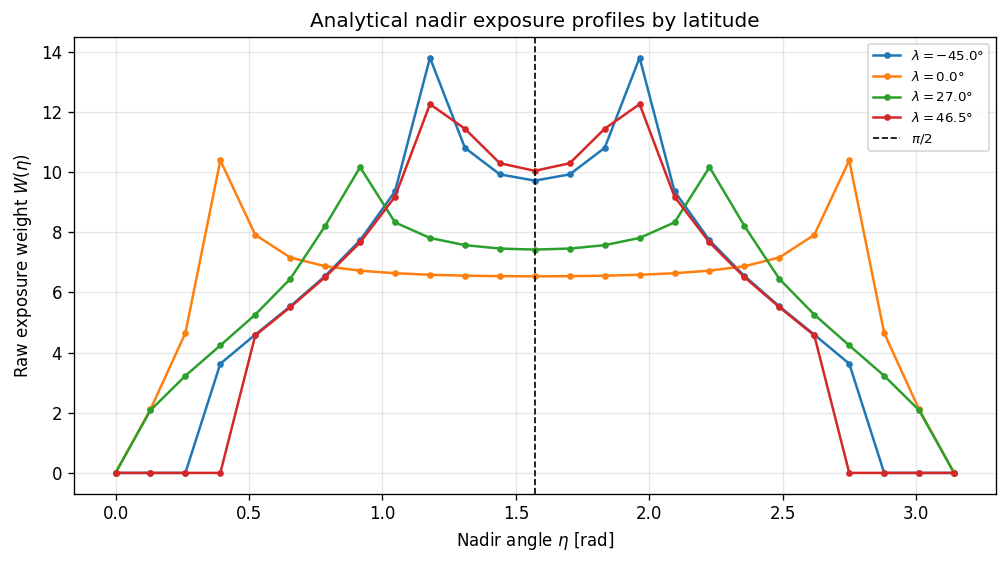

/mnt/v/output/diagnostic/earth/diagnostic3_fig3_exposure_vs_latitude.png


In [3]:
LATITUDES_DEG = [-45.0, 0.0, 27.0, 46.5]
NS_MATH = 25

fig, ax = plt.subplots(figsize=(8.5, 4.8))

for lat_deg in LATITUDES_DEG:
    exposure = ExposureParameters(
        detector_latitude_rad=math.radians(lat_deg),
        exposure_ns=NS_MATH,
        exposure_use_cache=False,
    )
    table = build_nadir_exposure(exposure=exposure, context=ctx, normalized=False)
    ax.plot(to_numpy(table.eta), to_numpy(table.exposure), marker="o", ms=3, label=rf"$\lambda={lat_deg:.1f}°$")

ax.axvline(math.pi / 2.0, color="black", ls="--", lw=1.0, label=r"$\pi/2$")
ax.set_xlabel(r"Nadir angle $\eta$ [rad]")
ax.set_ylabel(r"Raw exposure weight $W(\eta)$")
ax.set_title("Analytical nadir exposure profiles by latitude")
ax.legend(fontsize=8)

fig.tight_layout()
save_and_show("diagnostic3_fig3_exposure_vs_latitude.png", fig, output_dir=OUTPUT_DIR, show_plots=config.show_plots)

## 4. CSV Angle-Mode Conversion and Day/Night Slicing

A synthetic exposure CSV (a single `Exposure` column) is loaded in the three
supported angle conventions -- "Nadir" (passthrough), "Zenith" (reversed), and
"CosZenith" (resampled onto a $\cos\theta_z$ grid) -- and split into its
day/night halves.

**Expected results:** the Zenith curve should be the exact mirror image of the
Nadir curve; the CosZenith curve should be finite and non-negative everywhere;
the night-only eta grid should cover the lower half of $[0,\pi]$.

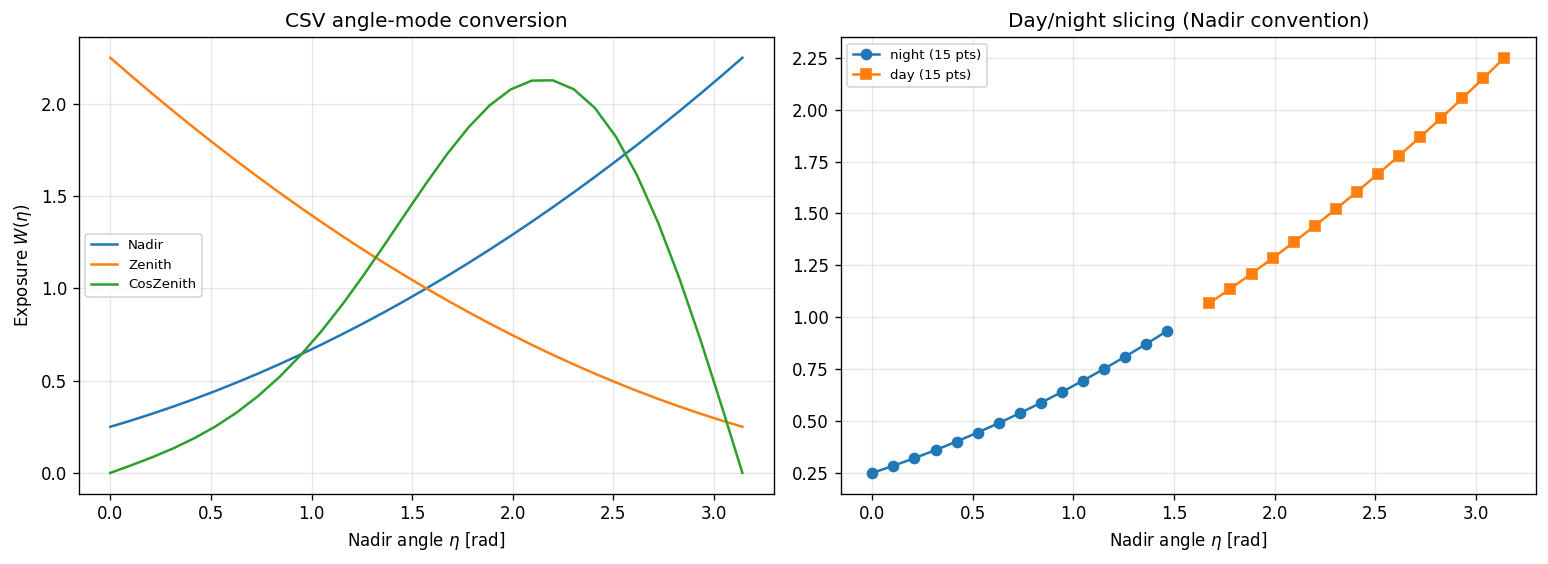

/mnt/v/output/diagnostic/earth/diagnostic3_fig4_csv_angle_modes.png
CSV file       : /mnt/v/output/diagnostic/earth/diagnostic3_synthetic_exposure.csv
night eta range: [0.000, 1.466]
day eta range  : [1.676, 3.142]


In [4]:
CSV_PATH = OUTPUT_DIR / "diagnostic3_synthetic_exposure.csv"
raw_values = (torch.linspace(0.5, 1.5, 31, device=ctx.device, dtype=ctx.dtype)) ** 2

with open(CSV_PATH, "w", encoding="utf-8") as handle:
    handle.write("Exposure\n")
    for value in raw_values.tolist():
        handle.write(f"{value}\n")

fig, axes = plt.subplots(1, 2, figsize=(13.0, 4.8))

for angle_mode in ["Nadir", "Zenith", "CosZenith"]:
    eta_mode, exposure_mode = nadir_exposure_from_csv(
        str(CSV_PATH), angle=angle_mode, daynight=None, device=ctx.device, dtype=ctx.dtype
    )
    axes[0].plot(to_numpy(eta_mode), to_numpy(exposure_mode), label=angle_mode)

eta_night, exposure_night = nadir_exposure_from_csv(str(CSV_PATH), angle="Nadir", daynight="night", device=ctx.device, dtype=ctx.dtype)
eta_day, exposure_day = nadir_exposure_from_csv(str(CSV_PATH), angle="Nadir", daynight="day", device=ctx.device, dtype=ctx.dtype)
axes[1].plot(to_numpy(eta_night), to_numpy(exposure_night), "o-", label=f"night ({eta_night.numel()} pts)")
axes[1].plot(to_numpy(eta_day), to_numpy(exposure_day), "s-", label=f"day ({eta_day.numel()} pts)")

axes[0].set_xlabel(r"Nadir angle $\eta$ [rad]")
axes[0].set_ylabel(r"Exposure $W(\eta)$")
axes[0].set_title("CSV angle-mode conversion")
axes[0].legend(fontsize=8)

axes[1].set_xlabel(r"Nadir angle $\eta$ [rad]")
axes[1].set_title("Day/night slicing (Nadir convention)")
axes[1].legend(fontsize=8)

fig.tight_layout()
save_and_show("diagnostic3_fig4_csv_angle_modes.png", fig, output_dir=OUTPUT_DIR, show_plots=config.show_plots)

print(f"CSV file       : {CSV_PATH}")
print(f"night eta range: [{float(eta_night.min()):.3f}, {float(eta_night.max()):.3f}]")
print(f"day eta range  : [{float(eta_day.min()):.3f}, {float(eta_day.max()):.3f}]")

## 5. NadirExposureTable Normalization and Interpolation

A synthetic table $W(\eta)=0.25+\sin^2\eta$ is normalized to unit trapezoidal
integral and then linearly interpolated on a fine query grid.

**Expected results:** the normalized table should integrate to exactly 1; the
interpolated curve should pass through every stored node and vary smoothly
between them.

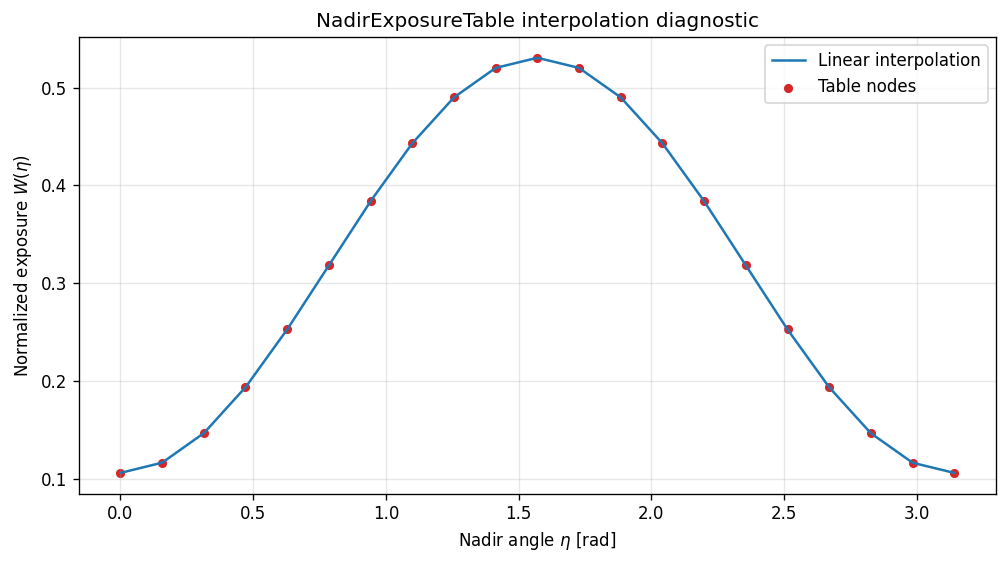

/mnt/v/output/diagnostic/earth/diagnostic3_fig5_table_interpolation.png
raw integral        : 2.356194
normalized integral : 1.0000000000 (expected 1.0)


In [5]:
eta_synthetic = torch.linspace(0.0, math.pi, 21, device=ctx.device, dtype=ctx.dtype)
exposure_synthetic = 0.25 + torch.sin(eta_synthetic) ** 2
table = NadirExposureTable(eta=eta_synthetic, exposure=exposure_synthetic)

raw_integral = float(torch.trapezoid(table.exposure, x=table.eta))
table.normalize_()
normalized_integral = float(torch.trapezoid(table.exposure, x=table.eta))

eta_query = torch.linspace(0.0, math.pi, 300, device=ctx.device, dtype=ctx.dtype)
exposure_query = table.interp(eta_query)

fig, ax = plt.subplots(figsize=(8.5, 4.8))
ax.plot(to_numpy(eta_query), to_numpy(exposure_query), label="Linear interpolation")
ax.scatter(to_numpy(table.eta), to_numpy(table.exposure), s=20, color="tab:red", label="Table nodes")
ax.set_xlabel(r"Nadir angle $\eta$ [rad]")
ax.set_ylabel(r"Normalized exposure $W(\eta)$")
ax.set_title("NadirExposureTable interpolation diagnostic")
ax.legend()

fig.tight_layout()
save_and_show("diagnostic3_fig5_table_interpolation.png", fig, output_dir=OUTPUT_DIR, show_plots=config.show_plots)

print(f"raw integral        : {raw_integral:.6f}")
print(f"normalized integral : {normalized_integral:.10f} (expected 1.0)")

## 6. Exposure-Integrated Probability Convergence

$\sum_\alpha P_{\rm int}(E)_\alpha$ must equal exactly 1 for a normalized
exposure table, at *any* grid size $N_\eta$, since it is just the exposure
weight integrated against the (pointwise unit-sum) Earth probability. This is
evaluated for a range of grid sizes to confirm the Riemann-sum step $\Delta\eta$
used in `pearth_integrated` now matches the exposure table's true point
spacing (the bug found while building the pytest suite for this notebook: the
old code used the ns-based `pi/exposure_ns` instead of the grid's actual
`eta[1]-eta[0] = pi/(exposure_ns-1)`, undercounting every exposure-integrated
quantity by a factor of exactly `(ns-1)/ns`).

**Expected results:** `sum_alpha P_int` should sit at 1.0 to machine precision
for every grid size shown, not just for large $N_\eta$.

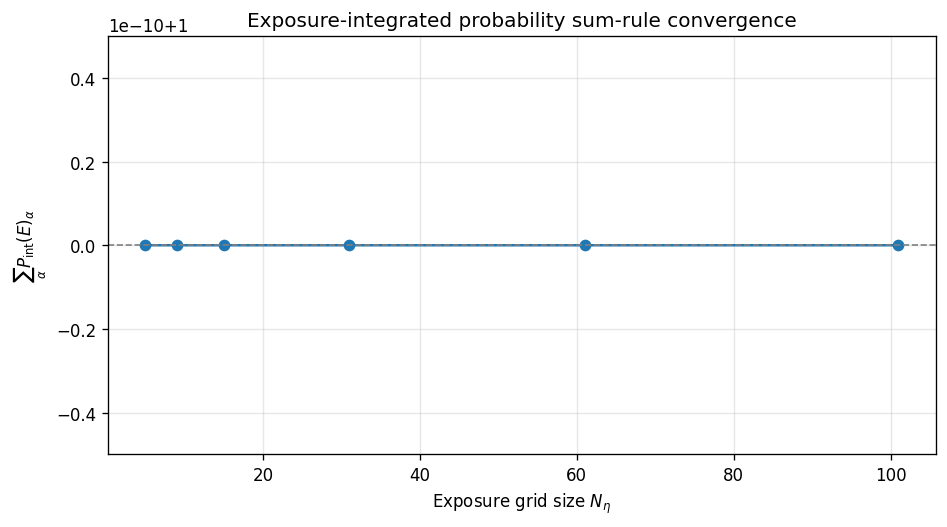

/mnt/v/output/diagnostic/earth/diagnostic3_fig6_sum_rule_convergence.png
   N_eta |    sum_alpha P_int
       5 |   1.00000000000000
       9 |   1.00000000000000
      15 |   1.00000000000000
      31 |   1.00000000000000
      61 |   1.00000000000000
     101 |   1.00000000000000


In [6]:
NS_VALUES = [5, 9, 15, 31, 61, 101]
sums = []

for ns in NS_VALUES:
    exposure = ExposureParameters(detector_latitude_rad=0.5, exposure_ns=ns, exposure_use_cache=False)
    P_int = pearth_integrated(
        MASS_WEIGHTS, earth_profile, oscillation, torch.tensor(1000.0, device=ctx.device, dtype=ctx.dtype),
        DEPTH_SURFACE_M, method="analytical", massbasis=True, exposure=exposure, context=ctx,
        normalized_exposure=True, reunitarize=True,
    )
    sums.append(float(torch.sum(P_int)))

fig, ax = plt.subplots(figsize=(8.0, 4.5))
ax.plot(NS_VALUES, sums, marker="o")
ax.axhline(1.0, color="gray", ls="--", lw=1.0)
ax.set_xlabel(r"Exposure grid size $N_\eta$")
ax.set_ylabel(r"$\sum_\alpha P_{\rm int}(E)_\alpha$")
ax.set_title("Exposure-integrated probability sum-rule convergence")
ax.set_ylim(1.0 - 5.0e-11, 1.0 + 5.0e-11)

fig.tight_layout()
save_and_show("diagnostic3_fig6_sum_rule_convergence.png", fig, output_dir=OUTPUT_DIR, show_plots=config.show_plots)

print(f"{'N_eta':>8} | {'sum_alpha P_int':>18}")
for ns, s in zip(NS_VALUES, sums):
    print(f"{ns:>8} | {s:>18.14f}")

## 7. Exposure-Integrated Probability versus Latitude

The exposure-averaged electron-flavour probability, for a fixed energy and
mass composition, evaluated across a range of detector latitudes.

**Expected results:** $P_{\rm int,e}$ should vary smoothly with latitude
(different latitudes sample different parts of the nadir-angle distribution
over the year) and remain within $[0,1]$ everywhere.

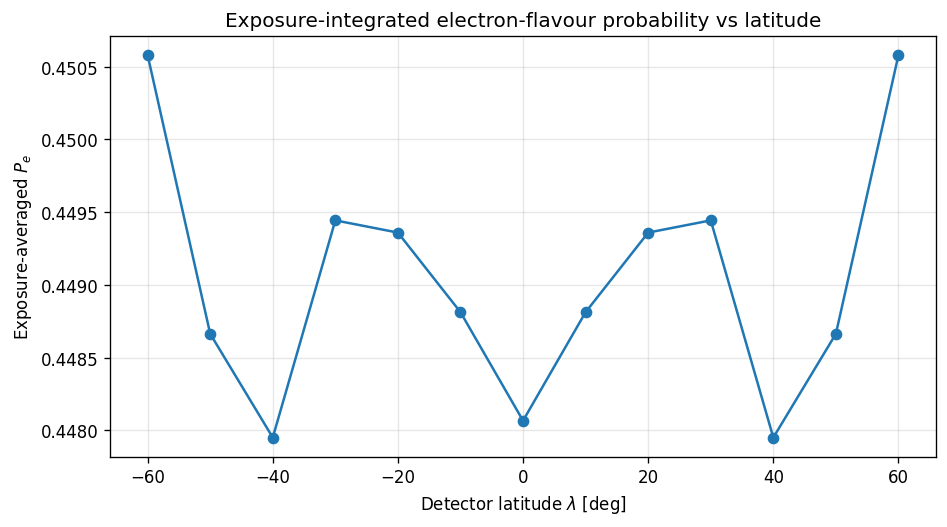

/mnt/v/output/diagnostic/earth/diagnostic3_fig7_probability_vs_latitude.png
P_e range over latitude scan: [0.4480, 0.4506]


In [7]:
LAT_SCAN_DEG = np.linspace(-60.0, 60.0, 13)
P_e_vs_lat = []

for lat_deg in LAT_SCAN_DEG:
    exposure = ExposureParameters(detector_latitude_rad=math.radians(float(lat_deg)), exposure_ns=31, exposure_use_cache=False)
    P_int = pearth_integrated(
        MASS_WEIGHTS, earth_profile, oscillation, torch.tensor(1000.0, device=ctx.device, dtype=ctx.dtype),
        DEPTH_SURFACE_M, method="analytical", massbasis=True, exposure=exposure, context=ctx,
        normalized_exposure=True,
    )
    P_e_vs_lat.append(float(P_int[0]))

fig, ax = plt.subplots(figsize=(8.0, 4.5))
ax.plot(LAT_SCAN_DEG, P_e_vs_lat, marker="o")
ax.set_xlabel(r"Detector latitude $\lambda$ [deg]")
ax.set_ylabel(r"Exposure-averaged $P_e$")
ax.set_title("Exposure-integrated electron-flavour probability vs latitude")

fig.tight_layout()
save_and_show("diagnostic3_fig7_probability_vs_latitude.png", fig, output_dir=OUTPUT_DIR, show_plots=config.show_plots)

print(f"P_e range over latitude scan: [{min(P_e_vs_lat):.4f}, {max(P_e_vs_lat):.4f}]")

## 8. Earth Flux from Probability

`earth_flux` applies a flux normalization and an illustrative energy spectrum
on top of `pearth`, and `earth_flux_integrated` does the same on top of the
exposure-averaged probability.

**Expected results:** the flux curve should be the probability curve scaled by
the flux/spectrum factors; the exposure-integrated flux should equal the
exposure-integrated probability times the same flux normalization.

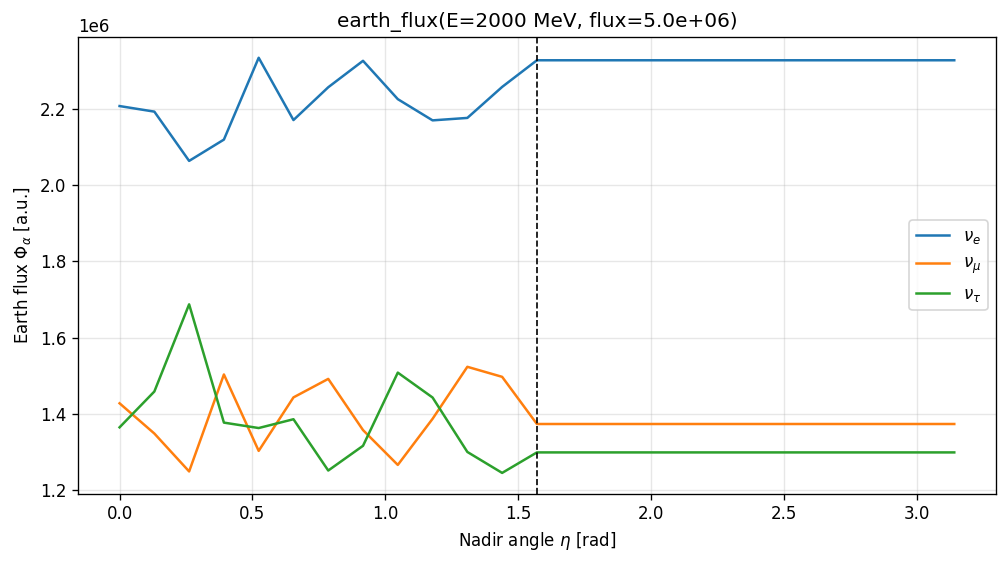

/mnt/v/output/diagnostic/earth/diagnostic3_fig8_earth_flux_vs_eta.png
exposure-integrated flux (E=1000 MeV): [2247715.903769 1406297.369409 1345986.726822]
exposure-integrated flux / normalization: [0.449543 0.281259 0.269197] (should sum to 1)


In [8]:
eta_flux = torch.linspace(0.0, math.pi, 25, device=ctx.device, dtype=ctx.dtype)
E_flux = torch.full_like(eta_flux, 2000.0)
FLUX_NORMALIZATION = 5.0e6

flux_vs_eta = earth_flux(
    MASS_WEIGHTS, earth_profile, oscillation, E_flux, eta_flux, DEPTH_SURFACE_M,
    flux=FLUX_NORMALIZATION, method="analytical", massbasis=True, reunitarize=True,
)

exposure = ExposureParameters(detector_latitude_rad=0.5, exposure_ns=31, exposure_use_cache=False)
flux_int = earth_flux_integrated(
    MASS_WEIGHTS, earth_profile, oscillation, torch.tensor(1000.0, device=ctx.device, dtype=ctx.dtype),
    DEPTH_SURFACE_M, flux=FLUX_NORMALIZATION, method="analytical", massbasis=True,
    exposure=exposure, context=ctx, normalized_exposure=True, reunitarize=True,
)

fig, ax = plt.subplots(figsize=(8.5, 4.8))
for idx, label in enumerate(FLAVOUR_LABELS):
    ax.plot(to_numpy(eta_flux), to_numpy(flux_vs_eta[:, idx]), label=label)
ax.axvline(math.pi / 2.0, color="black", ls="--", lw=1.0)
ax.set_xlabel(r"Nadir angle $\eta$ [rad]")
ax.set_ylabel(r"Earth flux $\Phi_\alpha$ [a.u.]")
ax.set_title(f"earth_flux(E=2000 MeV, flux={FLUX_NORMALIZATION:.1e})")
ax.legend()

fig.tight_layout()
save_and_show("diagnostic3_fig8_earth_flux_vs_eta.png", fig, output_dir=OUTPUT_DIR, show_plots=config.show_plots)

print(f"exposure-integrated flux (E=1000 MeV): {to_numpy(flux_int)}")
print(f"exposure-integrated flux / normalization: {to_numpy(flux_int / FLUX_NORMALIZATION)} (should sum to 1)")

## 9. Chunked versus Full-Batch Integration

`pearth_integrated` supports evaluating the exposure grid in chunks
(`chunk_eta`) to control memory usage. Chunking must not change the result.

**Expected results:** the chunked and full-batch results should agree to
numerical precision, for several chunk sizes.

In [9]:
exposure_chunk_test = ExposureParameters(detector_latitude_rad=0.5, exposure_ns=41, exposure_use_cache=False)
E_chunk_test = torch.tensor(1000.0, device=ctx.device, dtype=ctx.dtype)

P_full = pearth_integrated(
    MASS_WEIGHTS, earth_profile, oscillation, E_chunk_test, DEPTH_SURFACE_M,
    method="analytical", massbasis=True, exposure=exposure_chunk_test, context=ctx, chunk_eta=None,
)

chunk_sizes = [None, 5, 10, 20, 41]
max_diffs = []
for chunk_eta in chunk_sizes:
    P_chunk = pearth_integrated(
        MASS_WEIGHTS, earth_profile, oscillation, E_chunk_test, DEPTH_SURFACE_M,
        method="analytical", massbasis=True, exposure=exposure_chunk_test, context=ctx, chunk_eta=chunk_eta,
    )
    max_diffs.append(float(torch.max(torch.abs(P_chunk - P_full))))

print(f"{'chunk_eta':>10} | {'max |diff| vs chunk_eta=None':>30}")
for chunk_eta, diff in zip(chunk_sizes, max_diffs):
    print(f"{str(chunk_eta):>10} | {diff:>30.3e}")

print(f"\nall chunk sizes agree with the full batch: {all(d < 1.0e-10 for d in max_diffs)}")

 chunk_eta |   max |diff| vs chunk_eta=None
      None |                      0.000e+00
         5 |                      8.882e-16
        10 |                      8.882e-16
        20 |                      8.882e-16
        41 |                      0.000e+00

all chunk sizes agree with the full batch: True


## 10. Summary

In [10]:
print("Summary - Earth Diagnostic 3: Nadir Exposure and Flux")
print("-" * 60)
print(f"Loaded Earth model              : {earth_profile}")
print(f"Normalized synthetic table integral: {normalized_integral:.10f}")
print(f"Sum-rule convergence (all N_eta) : {[f'{s:.10f}' for s in sums]}")
print(f"P_e range over latitude scan     : [{min(P_e_vs_lat):.4f}, {max(P_e_vs_lat):.4f}]")
print(f"Chunked-vs-full max |diff|       : {max(max_diffs):.3e}")
print()
print("Pytest companions: tpeanuts.medium.earth.test.test5_flux, tpeanuts.medium.earth.test.test6_exposure")
print("Density/geometry companion: notebooks/diagnostic/earth/diagnostic1_earth_density.ipynb")
print("Evolutor/probability companion: notebooks/diagnostic/earth/diagnostic2_propagation.ipynb")

Summary - Earth Diagnostic 3: Nadir Exposure and Flux
------------------------------------------------------------
Loaded Earth model              : EarthProfile | model=even_power | n_shells=5 | r=[0.1920, 1.0000] R_E (6371 km scale) | depth=0 m | method=analytical | cpu / torch.float64
Normalized synthetic table integral: 1.0000000000
Sum-rule convergence (all N_eta) : ['1.0000000000', '1.0000000000', '1.0000000000', '1.0000000000', '1.0000000000', '1.0000000000']
P_e range over latitude scan     : [0.4480, 0.4506]
Chunked-vs-full max |diff|       : 8.882e-16

Pytest companions: tpeanuts.medium.earth.test.test5_flux, tpeanuts.medium.earth.test.test6_exposure
Density/geometry companion: notebooks/diagnostic/earth/diagnostic1_earth_density.ipynb
Evolutor/probability companion: notebooks/diagnostic/earth/diagnostic2_propagation.ipynb
